# Experimental MMM: multiple outcomes, one graph

This runnable example uses the **experimental** `MMM` API rather than the stable column-based MMM. Two continuous outcomes share a `target` dimension, while weekly counts use a Poisson likelihood and independent studies measure media effects on a `study` dimension. All three observed equations share the same media coefficient where relevant.

The data are synthetic. Short sampling keeps the notebook practical; its posterior estimates are illustrative, not validated production inference.


## Data enter at fit time

`Data("spend")` will be a lazy reference to a variable in an `xarray.Dataset`. Spend has `(date, channel)`, a centered price index has `(date, product)`, the two outcomes have `(date, product, target)`, weekly orders have `(date)`, and the calibration measurements have `(study, channel, target)`. There is no model-wide dimension declaration or hidden scaling.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc.dims as pmd
import xarray as xr
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.experimental import MMM, Data, Equation, MediaTransform
from pymc_marketing.terms import Intercept, Parameter, Transform

In [2]:
rng = np.random.default_rng(42)
dates = pd.date_range("2025-01-06", periods=22, freq="W-MON")
channels = ["search", "video"]
products = ["starter", "pro"]
targets = ["sales_index", "leads_index"]
studies = ["pilot_a", "pilot_b", "pilot_c"]
n_train = 18

spend = rng.uniform(0.2, 1.2, size=(len(dates), len(channels)))
time = np.arange(len(dates))
price_index = np.column_stack((0.20 * np.sin(time / 2), 0.20 * np.cos(time / 3)))

# Generate observations with the same fixed causal adstock and saturation used below.
weights = 0.4 ** np.arange(3)
weights /= weights.sum()
adstocked = np.zeros_like(spend)
for lag, weight in enumerate(weights):
    adstocked[lag:] += weight * spend[: len(dates) - lag]
media_signal = np.tanh(adstocked / 2)
true_media_beta = np.array([[0.70, 0.45], [0.35, 0.60]])
true_intercept = np.array([[0.50, 0.80], [0.90, 1.00]])
true_price_beta = np.array([-0.15, -0.30])
media_total = media_signal @ true_media_beta
true_mean = (
    true_intercept[None, :, :]
    + media_total[:, None, :]
    + price_index[:, :, None] * true_price_beta[None, :, None]
)
response = true_mean + rng.normal(size=true_mean.shape) * [0.07, 0.09]
orders = rng.poisson(np.exp(0.2 + 0.25 * media_total[:, 0]))
lift = true_media_beta[None, :, :] + rng.normal(0, 0.12, size=(len(studies), 2, 2))

inputs = xr.Dataset(
    {
        "spend": (("date", "channel"), spend),
        "price_index": (("date", "product"), price_index),
    },
    coords={"date": dates, "channel": channels, "product": products},
)
train = inputs.isel(date=slice(0, n_train)).assign_coords(target=targets, study=studies)
train["response"] = (("date", "product", "target"), response[:n_train])
train["orders"] = ("date", orders[:n_train])
train["lift"] = (("study", "channel", "target"), lift)
future = inputs.isel(date=slice(n_train, None))

print(
    "Training variables:", {name: array.dims for name, array in train.data_vars.items()}
)
print(
    "Future variables:", {name: array.dims for name, array in future.data_vars.items()}
)

Training variables: {'spend': ('date', 'channel'), 'price_index': ('date', 'product'), 'response': ('date', 'product', 'target'), 'orders': ('date',), 'lift': ('study', 'channel', 'target')}
Future variables: {'spend': ('date', 'channel'), 'price_index': ('date', 'product')}


## Equations declare likelihoods; terms declare computations

`MediaTransform` applies the configured carryover and saturation along `date`, and the named `channel` reduction is explicit. `media_beta(channel, target)` is one shared `Parameter`: it contributes to both continuous outcomes, the Poisson order rate (using the first target), and the independent lift-study likelihood. A separate noise scale varies only by target.


In [3]:
signal = MediaTransform(
    Data("spend"),
    GeometricAdstock(l_max=3, normalize=True, priors={"alpha": 0.4}),
    LogisticSaturation(priors={"lam": 1.0, "beta": 1.0}),
)
media_beta = Parameter(
    "media_beta", Prior("HalfNormal", sigma=1.0, dims=("channel", "target"))
)
price_beta = Parameter(
    "price_beta", Prior("Normal", mu=-0.2, sigma=0.25, dims="product")
)
noise = Parameter("noise", Prior("HalfNormal", sigma=0.2, dims="target"))
channel_contribution = Transform(
    signal * media_beta,
    lambda value: pmd.Deterministic(
        "channel_contribution", value, dims=("date", "channel", "target")
    ),
)
media_effect = Transform(channel_contribution, lambda value: value.sum(dim="channel"))
response_mean = Transform(
    Intercept(
        "baseline", prior=Prior("Normal", mu=0.7, sigma=0.5, dims=("product", "target"))
    )
    + media_effect
    + Data("price_index") * price_beta,
    lambda value: pmd.Deterministic(
        "response_mean", value, dims=("date", "product", "target")
    ),
)
response_equation = Equation(
    observed="response",
    mu=response_mean,
    likelihood=Prior("Normal"),
    parameters={"sigma": noise},
)
# Index 0 corresponds to "sales_index" in the declared target coordinate.
orders_equation = Equation(
    name="weekly_orders",
    observed="orders",
    mu=Transform(
        media_effect, lambda value: pmd.math.exp(0.2 + 0.25 * value[{"target": 0}])
    ),
    likelihood=Prior("Poisson"),
)
lift_equation = Equation(
    name="lift_studies",
    observed="lift",
    mu=media_beta,
    likelihood=Prior("Normal", sigma=0.12),
)
mmm = MMM(response_equation, orders_equation, lift_equation)

## Fit the joint graph

`fit(train)` supplies the inputs, observation values, and every labeled coordinate. The three likelihoods share one `media_beta` random variable by object identity. This intentionally small sampling run demonstrates the API, not convergence or parameter recovery; increase chains/draws and check diagnostics for real analysis.


In [4]:
idata = mmm.fit(
    train,
    draws=150,
    tune=150,
    chains=2,
    cores=1,
    random_seed=73,
    progressbar=False,
    compute_convergence_checks=False,
)
print("Free variables:", [variable.name for variable in mmm.model.free_RVs])
print("Observed equations:", [variable.name for variable in mmm.model.observed_RVs])
print(
    "Divergences in this illustrative run:",
    idata["sample_stats"]["diverging"].sum().item(),
)
idata["posterior"]["media_beta"].mean(("chain", "draw")).to_pandas().round(2)

NUTS[nutpie]: [noise, baseline, media_beta, price_beta]


Free variables: ['noise', 'baseline', 'media_beta', 'price_beta']
Observed equations: ['response', 'weekly_orders', 'lift_studies']
Divergences in this illustrative run: 0


target,sales_index,leads_index
channel,,
search,0.84,0.5
video,0.38,0.6


## Forecast on a different dataset layout

`future` contains only predictors: no outcome, order counts, lift measurements, `target` coordinate, or `study` coordinate. Prediction restores fitted output-only labels without expanding predictors into a Cartesian grid. The date-dependent adstock term prepends measured training history, then returns only the requested future dates.


In [5]:
baseline = mmm.sample_posterior_predictive(
    future,
    var_names=[
        "response_mean",
        "response",
        "weekly_orders",
        "lift_studies",
        "channel_contribution",
    ],
    random_seed=202,
    progressbar=False,
)
print(
    "Predictive dimensions:",
    {name: array.dims for name, array in baseline.data_vars.items()},
)
print(
    "Restored study labels:", baseline["lift_studies"].coords["study"].values.tolist()
)
print("Future dates:", baseline["response_mean"].coords["date"].values)

Sampling: [lift_studies, response, weekly_orders]


Predictive dimensions: {'response_mean': ('chain', 'draw', 'date', 'product', 'target'), 'response': ('chain', 'draw', 'date', 'product', 'target'), 'weekly_orders': ('chain', 'draw', 'date'), 'lift_studies': ('chain', 'draw', 'study', 'channel', 'target'), 'channel_contribution': ('chain', 'draw', 'date', 'channel', 'target')}
Restored study labels: ['pilot_a', 'pilot_b', 'pilot_c']
Future dates: ['2025-05-12T00:00:00.000000' '2025-05-19T00:00:00.000000'
 '2025-05-26T00:00:00.000000' '2025-06-02T00:00:00.000000']


## A different future spend plan, not a different fitted model

Increase only future `search` spend by 30%. Both calls reuse the fitted parameter draws; comparing the deterministic `response_mean` isolates the modeled response from new observation noise. This is a scenario calculation under the specified graph, not proof of a causal effect.


In [6]:
alternative = future.copy(deep=True)
alternative["spend"].loc[{"channel": "search"}] = (
    alternative["spend"].sel(channel="search") * 1.30
)
boosted = mmm.sample_posterior_predictive(
    alternative, var_names=["response_mean"], random_seed=202, progressbar=False
)
uplift = (boosted["response_mean"] - baseline["response_mean"]).sel(
    target="sales_index"
)
print(
    "Mean sales-index difference from the proposed plan:",
    round(uplift.mean().item(), 3),
)
if not (uplift > 0).all().item():
    raise AssertionError("Increasing search spend must raise the modeled mean")

Sampling: []


Mean sales-index difference from the proposed plan: 0.053


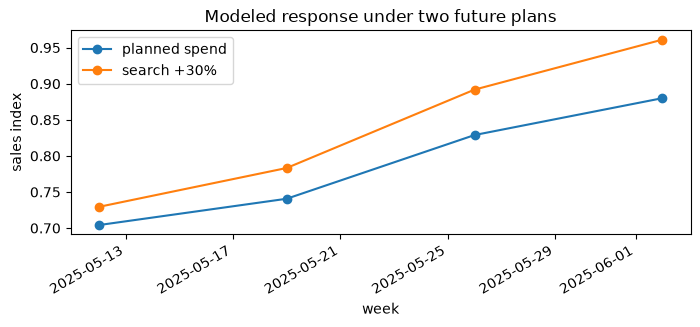

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))
for label, prediction in (("planned spend", baseline), ("search +30%", boosted)):
    curve = prediction["response_mean"].sel(product="starter", target="sales_index")
    average = curve.mean(("chain", "draw"))
    ax.plot(average.date.values, average.values, marker="o", label=label)
ax.set(
    title="Modeled response under two future plans", xlabel="week", ylabel="sales index"
)
ax.legend()
fig.autofmt_xdate()
plt.show()

## Explicit temporal boundary policy

`include_last_observations=False` treats the supplied future data as an independent scenario with zero adstock before its first date. The default instead carries over the preceding measured training spend. These are deliberately different assumptions, not interchangeable forecasts.


In [8]:
cold_start = mmm.sample_posterior_predictive(
    future,
    var_names=["response_mean"],
    include_last_observations=False,
    random_seed=202,
    progressbar=False,
)
first_week = dict(product="starter", target="sales_index")
with_history = baseline["response_mean"].sel(**first_week).isel(date=0).mean().item()
without_history = (
    cold_start["response_mean"].sel(**first_week).isel(date=0).mean().item()
)
print(f"First future week, training history: {with_history:.3f}")
print(f"First future week, independent start: {without_history:.3f}")

Sampling: []


First future week, training history: 0.704
First future week, independent start: 0.584


## What this enables, and what it does not

One `target` dimension is convenient when outputs share a Normal likelihood and layout; the Poisson and study likelihoods are separate roots because their observation families and axes differ. The API does not automatically rescale data, infer reductions, or identify causal effects. Prediction can extend the `date` axis, while other fitted coordinate label sets stay fixed (reordering is allowed). Short MCMC runs and synthetic data are teaching devices, not a replacement for prior predictive checks, convergence diagnostics, and validation on real data.


In [9]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Mon, 28 Sep 2026

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.15.0

pymc_marketing: 1.1.0

matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
pymc          : 6.3.2
pymc_extras   : 0.15.1
pymc_marketing: 1.1.0
xarray        : 2026.4.0

Watermark: 2.6.0

